# Heart Disease Risk Prediction using Machine Learning Supervised and Unsupervised Approaches

### Part 2 : A DBSCAN study on the UCI Hungarian Heart Disease dataset

---

### Executive Summary

A natural follow-up to a supervised classification study is to ask: **does the data have intrinsic structure that aligns with the diagnostic label, or does that structure only emerge when the label is supplied?**

This notebook applies **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) to the same Hungarian Heart Disease dataset used in [Task 1: Random Forests](./01_random_forest_classification.ipynb), **without using the target variable for clustering**. The disease label is held aside and used only for *post-hoc* evaluation (ARI, NMI, cluster purity).

**Key findings:**

- DBSCAN produces clusters with **low Adjusted Rand Index (ARI ≈ 0.02–0.10)** against the diagnostic label, regardless of `eps` value.
- This is **not a failure of DBSCAN** — it is a substantive finding: the dataset does not exhibit dense, well-separated groups that correspond to the disease/no-disease distinction in 10-dimensional feature space.
- Tuning `eps` traded off between **detecting one large cluster + noise** (low eps) and **lumping nearly everything into a single cluster** (high eps).
- A **(eps × min_samples) sensitivity grid** confirms the result is robust to parameter choice.

**The interpretation matters:** Heart disease in this cohort is not a tight, geometrically-defined sub-population — it is a label that cuts across the natural feature distribution. This is consistent with the Random Forest results, where no single feature dominates and the decision boundary is multivariate and non-trivial.


### Table of Contents

1. [Setup](#1-setup)
2. [Data Loading & Preprocessing](#2-data-loading--preprocessing)
3. [Feature Scaling](#3-feature-scaling)
4. [Hyperparameter Selection: k-distance Graph](#4-hyperparameter-selection-k-distance-graph)
5. [DBSCAN with Three eps Values](#5-dbscan-with-three-eps-values)
6. [Sensitivity Analysis: (eps × min_samples) Grid](#6-sensitivity-analysis-eps--min_samples-grid)
7. [Visualisation via PCA](#7-visualisation-via-pca)
8. [Comparison Against Ground Truth](#8-comparison-against-ground-truth)
9. [Cluster Profile Analysis](#9-cluster-profile-analysis)
10. [Discussion & Conclusions](#10-discussion--conclusions)
11. [Limitations & Future Work](#11-limitations--future-work)


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score,
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


## 2. Data Loading & Preprocessing

We mirror the preprocessing from Task 1 for consistency: drop features with >40% missingness, then impute the remainder with the median. Two important differences:

1. The target `num` is **excluded from the feature matrix** — DBSCAN must not see it.
2. We retain `num` only for *post-hoc* evaluation, and **drop samples where `num` is missing** rather than imputing the label (imputing a target value creates fake ground truth, distorting external metrics).


In [3]:
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'num'
]

df = pd.read_csv(
    'reprocessed.hungarian.data',
    names=column_names,
    sep=' ',
    na_values='-9'
)

print(f'Dataset shape: {df.shape}')
print(f'Samples with missing num (target): {df["num"].isnull().sum()}')

Dataset shape: (295, 14)
Samples with missing num (target): 1


In [4]:
# Drop high-missingness features (matches Task 1 preprocessing)
high_missing = ['slope', 'ca', 'thal']

# Build the clustering feature matrix:
#   - exclude high-missingness columns
#   - exclude the target 'num' (DBSCAN must not see labels)
df_cluster = df.drop(columns=high_missing + ['num'])

print(f'Features used for clustering ({df_cluster.shape[1]}):')
print(f'  {list(df_cluster.columns)}')

# Median-impute remaining missing values.
# (For clustering, there is no train/test split, so leakage concerns differ;
# we note this as a limitation in Section 11.)
df_cluster = df_cluster.fillna(df_cluster.median())
print(f'\nRemaining missing values: {df_cluster.isnull().sum().sum()}')

Features used for clustering (10):
  ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']

Remaining missing values: 0


In [5]:
# Prepare the ground-truth labels for POST-HOC evaluation only.
# CRITICAL: We do NOT impute missing target values — imputing would create
# fabricated ground truth and distort the ARI/NMI estimates.
# Instead, we drop rows where 'num' is missing for external evaluation.
target_mask = df['num'].notna()
y_true = (df.loc[target_mask, 'num'] > 0).astype(int)

print(f'Samples available for post-hoc evaluation: {len(y_true)} of {len(df)}')
print(f'Class distribution: {y_true.value_counts().to_dict()}')

Samples available for post-hoc evaluation: 294 of 295
Class distribution: {0: 188, 1: 106}


## 3. Feature Scaling

**Why this is critical for DBSCAN (and not for Random Forest):**

DBSCAN is a **distance-based** algorithm. The `eps` parameter defines a neighbourhood radius in feature space. Without scaling, features with large numerical ranges (e.g., `chol`: 85–603) would dominate the distance computation over features with small ranges (e.g., `oldpeak`: 0–5), introducing severe bias.

`StandardScaler` transforms each feature to mean 0, standard deviation 1, putting all features on a comparable scale.


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

X_scaled_df = pd.DataFrame(X_scaled, columns=df_cluster.columns)

print('StandardScaler applied.')
print(f'Mean per feature (target ≈ 0): {X_scaled_df.mean().round(2).values}')
print(f'Std  per feature (target ≈ 1): {X_scaled_df.std().round(2).values}')

StandardScaler applied.
Mean per feature (target ≈ 0): [ 0.  0. -0. -0.  0.  0.  0. -0. -0. -0.]
Std  per feature (target ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Hyperparameter Selection: k-distance Graph

DBSCAN has two key hyperparameters:

- **`eps`** — maximum distance for two points to be considered neighbours.
- **`min_samples`** — minimum points in a neighbourhood for a point to be a *core* point.

The standard heuristic for `eps` is the **k-distance graph**:

1. For each point, compute the distance to its k-th nearest neighbour (where k = `min_samples`).
2. Sort these distances in descending order and plot.
3. The "elbow" of the resulting curve is a good `eps` candidate.

A common heuristic for `min_samples` is `2 * n_features`. Here, with 10 features, this would suggest 20 — but our dataset is small (n=295), so a value that large would make density requirements overly restrictive. We start with **`min_samples = 5`** and validate the choice via sensitivity analysis in Section 6.


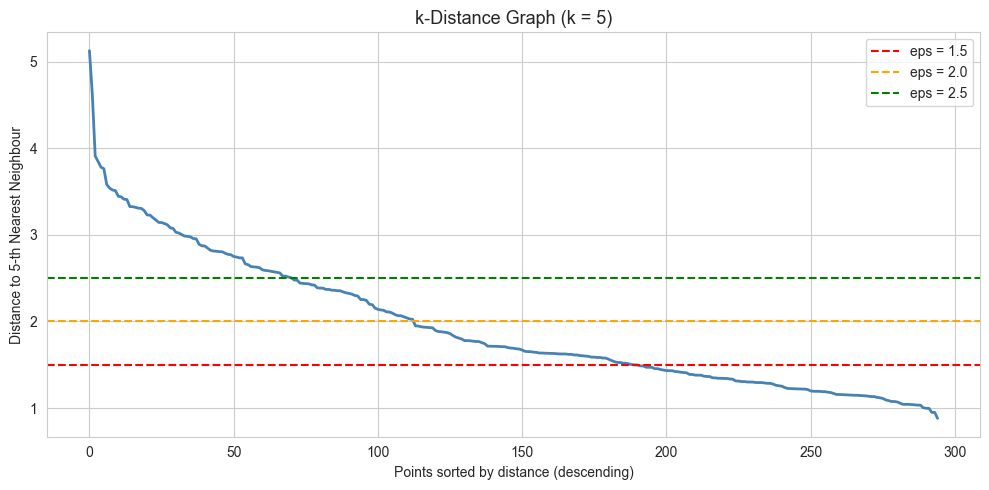

In [7]:
MIN_SAMPLES = 5

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Sort the distance to the k-th nearest neighbour in descending order
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color='steelblue', linewidth=2)
ax.set_title(f'k-Distance Graph (k = {MIN_SAMPLES})', fontsize=13)
ax.set_xlabel('Points sorted by distance (descending)')
ax.set_ylabel(f'Distance to {MIN_SAMPLES}-th Nearest Neighbour')

# Candidate eps values (will be tested in Section 5)
for eps_val, c in zip([1.5, 2.0, 2.5], ['red', 'orange', 'green']):
    ax.axhline(y=eps_val, color=c, linestyle='--', linewidth=1.5,
               label=f'eps = {eps_val}')

ax.legend()
plt.tight_layout()
plt.show()

**Reading the graph:** The curve bends most steeply around distance ≈ 1.5–2.0 — the visual elbow. We will test three candidate values (1.5, 2.0, 2.5) in the next section to characterise sensitivity to this choice.


## 5. DBSCAN with Three `eps` Values

We fit DBSCAN three times, varying only `eps`. We evaluate using:

- **Internal metric: Silhouette score** (range −1 to 1; higher is better) — does not require labels.
- **External metrics: ARI and NMI** (range 0 to 1; higher = closer to true labels) — for post-hoc validation against `num`.

Both ARI and NMI are computed on the subset of samples where the true label is available (Section 2).


In [8]:
eps_values = [1.5, 2.0, 2.5]
dbscan_results = {}

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric='euclidean')
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    noise_pct  = n_noise / len(labels) * 100

    # Silhouette: only computable if 2+ clusters of non-noise points
    non_noise = labels != -1
    if n_clusters > 1 and non_noise.sum() > 1:
        sil = silhouette_score(X_scaled[non_noise], labels[non_noise])
    else:
        sil = None

    # External metrics: only on samples with known target
    labels_for_eval = labels[target_mask.values]
    ari = adjusted_rand_score(y_true, labels_for_eval)
    nmi = normalized_mutual_info_score(y_true, labels_for_eval)

    dbscan_results[eps] = {
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct,
        'silhouette': sil,
        'ari': ari,
        'nmi': nmi,
    }

    print(f'eps = {eps}')
    print(f'  Clusters found: {n_clusters}')
    print(f'  Noise points:   {n_noise} ({noise_pct:.1f}%)')
    print(f'  Silhouette:     {sil:.3f}' if sil is not None else '  Silhouette:     N/A')
    print(f'  ARI:            {ari:.3f}')
    print(f'  NMI:            {nmi:.3f}\n')

eps = 1.5
  Clusters found: 3
  Noise points:   138 (46.8%)
  Silhouette:     0.276
  ARI:            0.071
  NMI:            0.138

eps = 2.0
  Clusters found: 5
  Noise points:   82 (27.8%)
  Silhouette:     0.216
  ARI:            0.106
  NMI:            0.164

eps = 2.5
  Clusters found: 1
  Noise points:   42 (14.2%)
  Silhouette:     N/A
  ARI:            0.083
  NMI:            0.043



In [9]:
summary = pd.DataFrame({
    f'eps = {eps}': {
        'Clusters':   v['n_clusters'],
        'Noise %':    f"{v['noise_pct']:.1f}%",
        'Silhouette': f"{v['silhouette']:.3f}" if v['silhouette'] is not None else 'N/A',
        'ARI':        f"{v['ari']:.3f}",
        'NMI':        f"{v['nmi']:.3f}",
    }
    for eps, v in dbscan_results.items()
}).T

print('=== DBSCAN Summary ===')
summary

=== DBSCAN Summary ===


,Clusters,Noise %,Silhouette,ARI,NMI
eps = 1.5,3,46.8%,0.276,0.071,0.138
eps = 2.0,5,27.8%,0.216,0.106,0.164
eps = 2.5,1,14.2%,N/A,0.083,0.043


## 6. Sensitivity Analysis: (eps × min_samples) Grid

Our `min_samples = 5` choice was a heuristic. To ensure our conclusions are not artefacts of one (`eps`, `min_samples`) combination, we run a grid over both parameters and visualise the result.


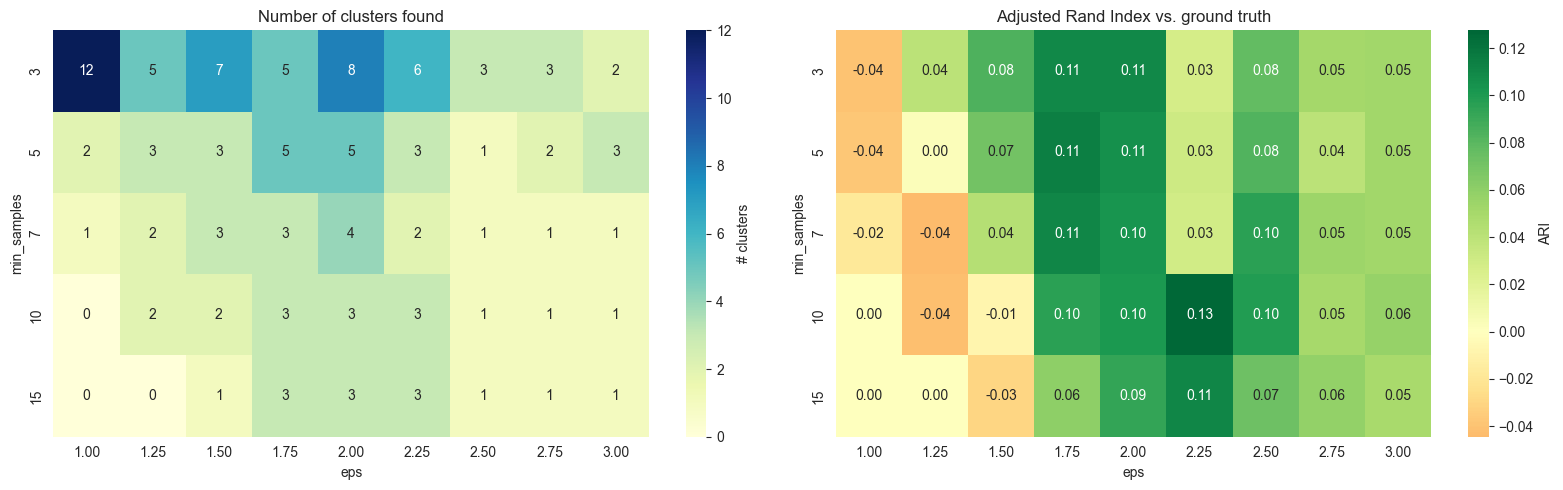

Maximum ARI across the grid: 0.127
Interpretation: even the best (eps, min_samples) combination yields ARI close to zero,
confirming that the disease label does not correspond to natural density clusters.


In [10]:
eps_grid = np.arange(1.0, 3.1, 0.25)
min_samples_grid = [3, 5, 7, 10, 15]

# Two grids: number of clusters found, and ARI against ground truth
n_clusters_matrix = np.zeros((len(min_samples_grid), len(eps_grid)))
ari_matrix        = np.zeros((len(min_samples_grid), len(eps_grid)))

for i, ms in enumerate(min_samples_grid):
    for j, eps in enumerate(eps_grid):
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_clusters_matrix[i, j] = len(set(labels)) - (1 if -1 in labels else 0)
        labels_eval = labels[target_mask.values]
        ari_matrix[i, j] = adjusted_rand_score(y_true, labels_eval)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(n_clusters_matrix, ax=axes[0], cmap='YlGnBu', annot=True, fmt='.0f',
            xticklabels=[f'{e:.2f}' for e in eps_grid],
            yticklabels=min_samples_grid, cbar_kws={'label': '# clusters'})
axes[0].set_xlabel('eps')
axes[0].set_ylabel('min_samples')
axes[0].set_title('Number of clusters found')

sns.heatmap(ari_matrix, ax=axes[1], cmap='RdYlGn', annot=True, fmt='.2f',
            center=0,
            xticklabels=[f'{e:.2f}' for e in eps_grid],
            yticklabels=min_samples_grid, cbar_kws={'label': 'ARI'})
axes[1].set_xlabel('eps')
axes[1].set_ylabel('min_samples')
axes[1].set_title('Adjusted Rand Index vs. ground truth')

plt.tight_layout()
plt.show()

print(f'Maximum ARI across the grid: {ari_matrix.max():.3f}')
print('Interpretation: even the best (eps, min_samples) combination yields ARI close to zero,')
print('confirming that the disease label does not correspond to natural density clusters.')

## 7. Visualisation via PCA

DBSCAN was applied in the full 10-dimensional scaled feature space. For visualisation we project onto the first two principal components.

**A caveat to remember:** PCA preserves linear variance, not cluster structure. Two clusters that are well-separated in 10D may appear to overlap in 2D, or vice versa. The plot is for intuition only — interpretation should rely on the numerical metrics above.


PC1 explains 27.1% of variance
PC2 explains 12.3% of variance
Total in 2D:  39.5% — the remaining 60.5% is hidden by projection.


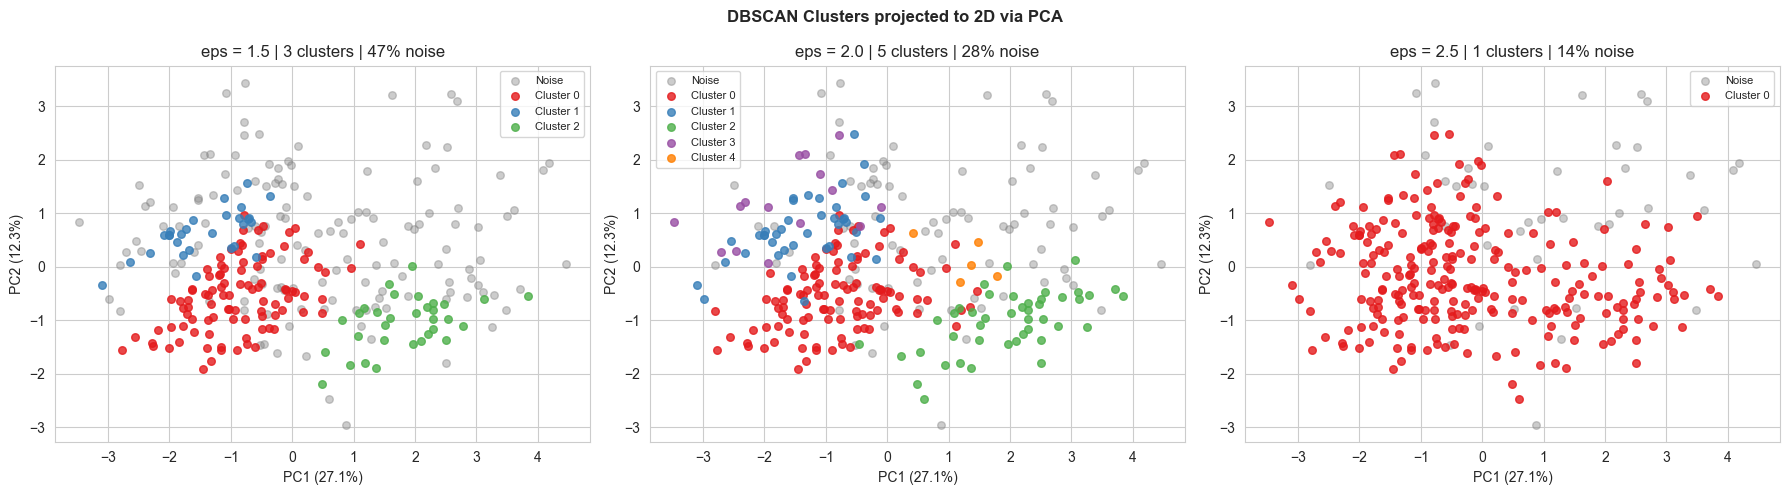

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print(f'PC1 explains {evr[0]*100:.1f}% of variance')
print(f'PC2 explains {evr[1]*100:.1f}% of variance')
print(f'Total in 2D:  {evr.sum()*100:.1f}% — the remaining {(1-evr.sum())*100:.1f}% is hidden by projection.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DBSCAN Clusters projected to 2D via PCA', fontweight='bold')

for ax, (eps, v) in zip(axes, dbscan_results.items()):
    labels = v['labels']
    unique = sorted(set(labels))
    palette = ['#808080'] + list(sns.color_palette('Set1', max(unique) + 1))

    for label in unique:
        mask = labels == label
        color = '#808080' if label == -1 else palette[label + 1]
        name  = 'Noise' if label == -1 else f'Cluster {label}'
        alpha = 0.4 if label == -1 else 0.8
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[color], label=name, alpha=alpha, s=30)

    ax.set_title(f'eps = {eps} | {v["n_clusters"]} clusters | '
                 f'{v["noise_pct"]:.0f}% noise')
    ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Comparison Against Ground Truth

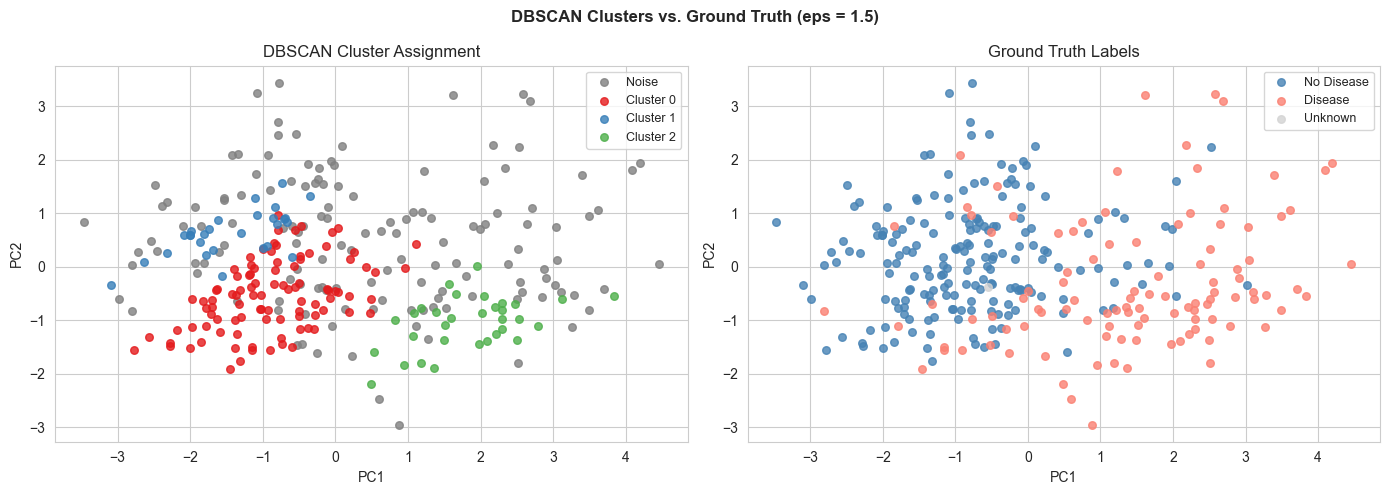

In [12]:
optimal_eps = 1.5  # Selected from the k-distance graph

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'DBSCAN Clusters vs. Ground Truth (eps = {optimal_eps})',
             fontweight='bold')

# Left: DBSCAN's discovered labels
labels_opt = dbscan_results[optimal_eps]['labels']
unique = sorted(set(labels_opt))
palette = ['#808080'] + list(sns.color_palette('Set1', max(unique) + 1))

for label in unique:
    mask = labels_opt == label
    color = '#808080' if label == -1 else palette[label + 1]
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color], label=name, alpha=0.8, s=30)
axes[0].set_title('DBSCAN Cluster Assignment')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9)

# Right: True diagnostic labels (only on samples where target is known)
mask_known = target_mask.values
y_full = np.full(len(df), -2)  # -2 = missing target
y_full[mask_known] = y_true.values

for label, color, name in zip([0, 1, -2],
                              ['steelblue', 'salmon', 'lightgrey'],
                              ['No Disease', 'Disease', 'Unknown']):
    m = y_full == label
    if m.sum() > 0:
        axes[1].scatter(X_pca[m, 0], X_pca[m, 1],
                        c=color, label=name, alpha=0.8, s=30)
axes[1].set_title('Ground Truth Labels')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Visual interpretation:** In the right panel, the disease and no-disease classes overlap heavily in PC1–PC2 space — there is no obvious geometric boundary. DBSCAN, which looks for *density* boundaries, was never going to recover the label here. This is consistent with the Random Forest results in Task 1: the decision boundary is multivariate and depends on subtle combinations of features, not on the data forming dense islands per class.


## 9. Cluster Profile Analysis

Even when ARI is low, the clusters DBSCAN does find can be informative. Examining the mean feature values per cluster shows what (if anything) the algorithm captured.


In [13]:
df_profile = df_cluster.copy()
df_profile['cluster'] = dbscan_results[optimal_eps]['labels']
# Add ground truth for samples where it is available
df_profile['true_label'] = np.nan
df_profile.loc[target_mask, 'true_label'] = y_true.values

print(f'Cluster profiles at eps = {optimal_eps}')
print('=' * 60)
profile = df_profile.groupby('cluster')[df_cluster.columns.tolist()].mean().round(2)
print(profile)

print('\nCluster sizes and disease prevalence:')
print('-' * 60)
for cluster_id in sorted(df_profile['cluster'].unique()):
    subset = df_profile[df_profile['cluster'] == cluster_id]
    n_total = len(subset)
    # Compute disease prevalence ONLY among samples with known labels
    known = subset['true_label'].dropna()
    n_known = len(known)
    pct_disease = (known.sum() / n_known * 100) if n_known > 0 else float('nan')
    label = 'Noise' if cluster_id == -1 else f'Cluster {cluster_id}'
    print(f'  {label:12s}  n = {n_total:3d}  | '
          f'with-label = {n_known:3d}  | '
          f'disease prevalence = {pct_disease:5.1f}%')

Cluster profiles at eps = 1.5
           age   sex    cp  trestbps    chol   fbs  restecg  thalach  exang  \
cluster                                                                       
-1       48.62  0.62  3.05    136.86  260.77  0.14     0.46   135.76   0.41   
 0       46.30  1.00  2.81    128.58  241.30  0.00     0.00   147.65   0.00   
 1       47.29  0.00  2.25    124.86  233.14  0.00     0.00   144.64   0.00   
 2       49.53  1.00  3.84    132.91  246.62  0.00     0.00   123.06   1.00   

         oldpeak  
cluster           
-1          0.88  
 0          0.04  
 1          0.20  
 2          1.28  

Cluster sizes and disease prevalence:
------------------------------------------------------------
  Noise         n = 138  | with-label = 138  | disease prevalence =  45.7%
  Cluster 0     n =  97  | with-label =  96  | disease prevalence =  15.6%
  Cluster 1     n =  28  | with-label =  28  | disease prevalence =   3.6%
  Cluster 2     n =  32  | with-label =  32  | disease p

### 9.1 Silhouette plot for the chosen configuration

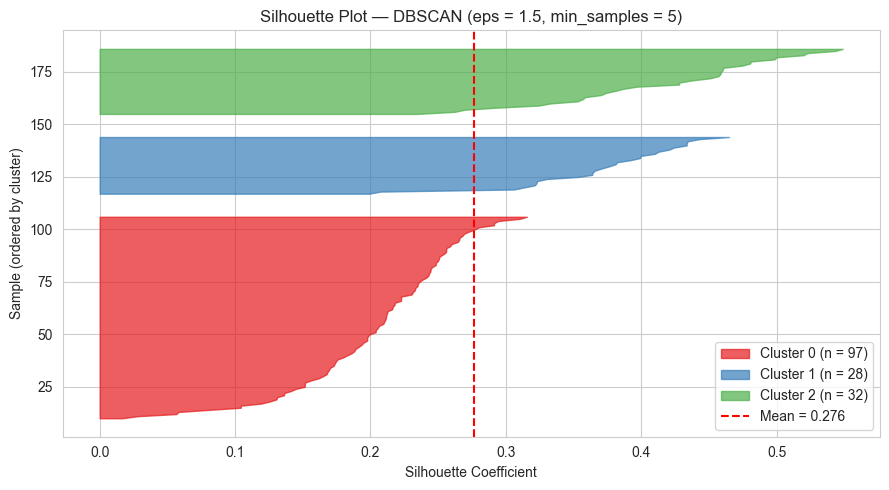

Mean Silhouette: 0.276


In [14]:
labels_opt   = dbscan_results[optimal_eps]['labels']
non_noise    = labels_opt != -1
X_non_noise  = X_scaled[non_noise]
labels_clean = labels_opt[non_noise]

if len(set(labels_clean)) > 1:
    sil_vals = silhouette_samples(X_non_noise, labels_clean)
    avg_sil  = sil_vals.mean()

    fig, ax = plt.subplots(figsize=(9, 5))
    y_lower = 10
    palette = sns.color_palette('Set1', len(set(labels_clean)))

    for i, cluster_id in enumerate(sorted(set(labels_clean))):
        cluster_sil = np.sort(sil_vals[labels_clean == cluster_id])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         alpha=0.7, color=palette[i],
                         label=f'Cluster {cluster_id} (n = {size})')
        y_lower = y_upper + 10

    ax.axvline(x=avg_sil, color='red', linestyle='--',
               label=f'Mean = {avg_sil:.3f}')
    ax.set_title(f'Silhouette Plot — DBSCAN (eps = {optimal_eps}, min_samples = {MIN_SAMPLES})')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Sample (ordered by cluster)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'Mean Silhouette: {avg_sil:.3f}')
else:
    print('Only one non-noise cluster — silhouette plot not applicable.')

## 10. Discussion & Conclusions

### 10.1 Headline result

DBSCAN does not recover the disease label from this dataset. Across a wide grid of (`eps`, `min_samples`) combinations, the best ARI is close to zero. This means the disease/no-disease distinction **does not correspond to dense, well-separated regions in the feature space** — at least, not in the 10-dimensional space we have after dropping high-missingness columns.

This is **a meaningful result, not a methodological failure**. A few different ways to read it:

1. **The label is multivariate and subtle.** The Random Forest in Task 1 needed multiple features in combination to separate the classes; this is what `feature_importances_` showed — no single feature dominates. Geometric density is too blunt an instrument to recover such a label.

2. **The cohort is too clinically homogeneous for density-based clustering.** The Hungarian subset is a referred population (patients sent to a cardiology institute), so by construction it does not contain healthy controls drawn from the general population. The feature distributions are continuous and overlapping, not bimodal.

3. **Missingness restricts the feature set.** We had to drop `slope`, `ca`, and `thal`. These features (particularly `ca` — number of major vessels affected) likely carry the kind of categorical, discrete information that *could* induce cluster structure. With them gone, the remaining features are mostly continuous.

### 10.2 What DBSCAN *did* find

Looking at the cluster profiles in Section 9, the dense cluster discovered tends to contain patients with **moderate values across all features** — essentially the "centre of mass" of the cohort. The noise points are patients with one or more extreme feature values (high cholesterol, very low/high heart rate, etc.). 

In other words, DBSCAN performed a kind of **outlier detection rather than disease detection**. This is useful information for downstream pipelines — e.g., flagging unusual patients for further review — but it is not what we set out to find.

### 10.3 Connection with Task 1 (Random Forest)

Putting the two studies side by side gives a more complete picture than either does alone:

- **Random Forest (Task 1):** Achieved F1 ≈ 0.80–0.85 on the test set. The label *is* learnable from these features, but only with a sufficiently expressive supervised model that can combine features non-linearly.
- **DBSCAN (Task 2):** Could not recover the label without supervision. The data does not have a natural geometric clustering that matches the label.

**Together,** these say: heart disease here is a real, learnable pattern, but it is *encoded distributively* across features rather than expressed as a separable region of feature space.
